<h1>1. Import libraries</h1>

In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

################## For training task ##################
import torch
import torchvision
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
import albumentations as A
from torchvision.transforms import InterpolationMode
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset
configs = {
    "image_folder": '/kaggle/input/datasets/azurebob2/tumormultitaskdataset/images/',
    "mask_folder": '/kaggle/input/datasets/azurebob2/tumormultitaskdataset/masks/',
    "image_size": 224
}

class_names = {0: "noTumor", 1: "meningioma", 2: "glioma", 3: "pituitary"}

<h1>2. Set up baseline for training, validation, testing stage</h1>
<h1>2.1. Loading and Setting up Dataset</h1>

In [4]:
image_paths = []

allTumors = os.listdir(configs["image_folder"])
for i in range(len(allTumors)):
    tumor_img_path = allTumors[i]
    #tumor_mask_path = os.path.join(configs['mask_folder'], allTumors[i].replace(".png", ".npy"))
    image_paths.append(tumor_img_path)


#print(len(image_paths))
#print(len(mask_paths))
divided_dataset_img = {0:[], 1:[], 2:[], 3:[]}
for idx in range(len(image_paths)):
    for k, v in class_names.items():
        if v in image_paths[idx]:
            divided_dataset_img[k].append(image_paths[idx])
            break
trainImagePaths = []
validImagePaths = []
testImagePaths = []
ratio = 0.8
for k, v in class_names.items():
    idx_split = round(ratio * len(divided_dataset_img[k]))
    trainImagePaths.extend(divided_dataset_img[k][:idx_split])

    valid_test_image_paths = divided_dataset_img[k][idx_split:]
    
    idx_split = int(len(valid_test_image_paths) / 2)
 
    validImagePaths.extend(valid_test_image_paths[:idx_split])
    testImagePaths.extend(valid_test_image_paths[idx_split:])
    
print(f"Train images: {len(trainImagePaths)}")
print(f"Valid images: {len(validImagePaths)}")
print(f"Test images: {len(testImagePaths)}")
    

Train images: 3116
Valid images: 389
Test images: 390


<h1>2.2. Create Data loader for Tumor dataset!</h1>
<h1>2.2.1. Check albumentation for 1 image(how it looks like?)</h1>

Tumor Label: meningioma
Image shape: (224, 224, 3)
Mask shape: (224, 224)


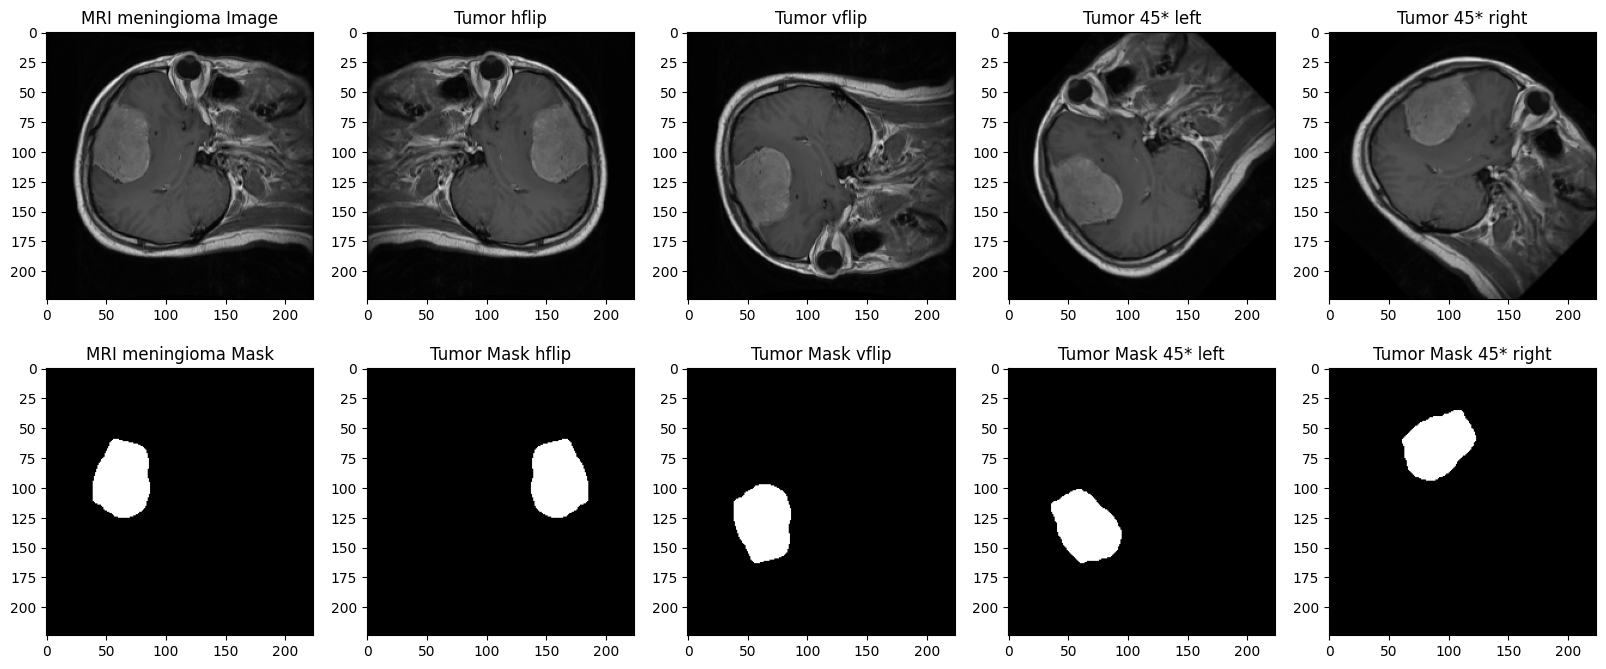

In [5]:
image_path2Show = trainImagePaths[1000]

reverse_class = {v: k for k, v in class_names.items()}

label = image_path2Show.split(".")[0].split("_")[1]

key = reverse_class[label]

print("Tumor Label:", class_names[key])

image2Show = cv2.imread(os.path.join(configs['image_folder'], image_path2Show))[:,:,::-1]
image2Show = cv2.resize(image2Show, (configs["image_size"], configs["image_size"]))
image2Show_hflip = cv2.flip(image2Show, 1)
image2Show_vflip = cv2.flip(image2Show, 0)
(h, w) = image2Show.shape[:2]
center = (w // 2, h // 2)

M = cv2.getRotationMatrix2D(center, 45, 1.0)  # 45° left
image2Show45left = cv2.warpAffine(image2Show, M, (w, h))
M = cv2.getRotationMatrix2D(center, -45, 1.0)  # 45° right
image2Show45right = cv2.warpAffine(image2Show, M, (w, h))

mask2Show = np.load(os.path.join(configs['mask_folder'], image_path2Show.replace(".png", ".npy")))
mask2Show = cv2.resize(mask2Show, (configs["image_size"], configs["image_size"]))
mask2Show_hflip = cv2.flip(mask2Show, 1)
mask2Show_vflip = cv2.flip(mask2Show, 0)

M = cv2.getRotationMatrix2D(center, 45, 1.0)  # 45° left
mask2Show45left = cv2.warpAffine(mask2Show, M, (w, h))
M = cv2.getRotationMatrix2D(center, -45, 1.0)  # 45° right
mask2Show45right = cv2.warpAffine(mask2Show, M, (w, h))

print("Image shape:", image2Show.shape)
print("Mask shape:", mask2Show.shape)
plt.figure(figsize=(20,8))

plt.subplot(2,5,1)
plt.title(f"MRI {label} Image")
plt.imshow(image2Show, cmap='gray')

plt.subplot(2,5,2)
plt.title("Tumor hflip")
plt.imshow(image2Show_hflip, cmap='gray')

plt.subplot(2,5,3)
plt.title("Tumor vflip")
plt.imshow(image2Show_vflip, cmap='gray')

plt.subplot(2,5,4)
plt.title("Tumor 45* left")
plt.imshow(image2Show45left, cmap='gray')

plt.subplot(2,5,5)
plt.title("Tumor 45* right")
plt.imshow(image2Show45right, cmap='gray')

plt.subplot(2,5,6)
plt.title(f"MRI {label} Mask")
plt.imshow(mask2Show, cmap='gray')

plt.subplot(2,5,7)
plt.title("Tumor Mask hflip")
plt.imshow(mask2Show_hflip, cmap='gray')

plt.subplot(2,5,8)
plt.title("Tumor Mask vflip")
plt.imshow(mask2Show_vflip, cmap='gray')

plt.subplot(2,5,9)
plt.title("Tumor Mask 45* left")
plt.imshow(mask2Show45left, cmap='gray')

plt.subplot(2,5,10)
plt.title("Tumor Mask 45* right")
plt.imshow(mask2Show45right, cmap='gray')
plt.show()

<h1>2.2.2. Setting up dataloader format for all images</h1>

In [6]:
dataset_mean = [0.15717137, 0.15716884, 0.1571717]
dataset_std  = [0.17174117, 0.17173925, 0.17174085]

train_tf = A.Compose(
    [
        A.Resize(configs["image_size"], configs["image_size"]),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Rotate(limit=360, border_mode=0, p=0.5),
        A.Normalize(mean=dataset_mean, std=dataset_std),
        ToTensorV2()
    ],
    additional_targets={'mask': 'mask'}
)

val_test_tf = A.Compose(
    [
        A.Resize(configs["image_size"], configs["image_size"]),
        A.Normalize(mean=dataset_mean, std=dataset_std),
        ToTensorV2()
    ],
    additional_targets={'mask': 'mask'}
)

In [17]:
class TumorDataset(Dataset):
    def __init__(self, configs, images, transform):
        self.images = images
        self.transform = transform
        self.configs = configs

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        print(img_path)
        reverse_class = {v: k for k, v in class_names.items()}
        label = img_path.split(".")[0].split("_")[1]
        label = reverse_class[label]

        image = cv2.imread(os.path.join(self.configs['image_folder'], img_path))[:,:,::-1]
        mask = np.load(os.path.join(self.configs['mask_folder'], img_path.replace(".png", ".npy")))
        # print(f"ehhh: {mask.shape}")

        
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        # print(image.shape)
        # print(mask.shape)
        # print(label)
        # print("--------------")

        return image, mask, label

In [18]:
train_data = TumorDataset(configs, trainImagePaths, transform=train_tf)
val_data   = TumorDataset(configs, validImagePaths, transform=val_test_tf)

train_loader = DataLoader(train_data, batch_size=20, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=20, shuffle=False)

<h1>2.3. Exploring Data</h1>
<h1>2.3.1 Training images in train</h1>

2432_glioma.png
1658_pituitary.png
441_noTumor.png
773_glioma.png
8_meningioma.png
2767_glioma.png
674_meningioma.png
192_meningioma.png
2311_glioma.png
240_meningioma.png
109_noTumor.png
512_noTumor.png
2073_glioma.png
1189_pituitary.png
625_noTumor.png
2992_glioma.png
1959_glioma.png
251_noTumor.png
2708_glioma.png
406_noTumor.png
torch.Size([20, 3, 224, 224])
torch.Size([20, 3, 224, 224])
ready


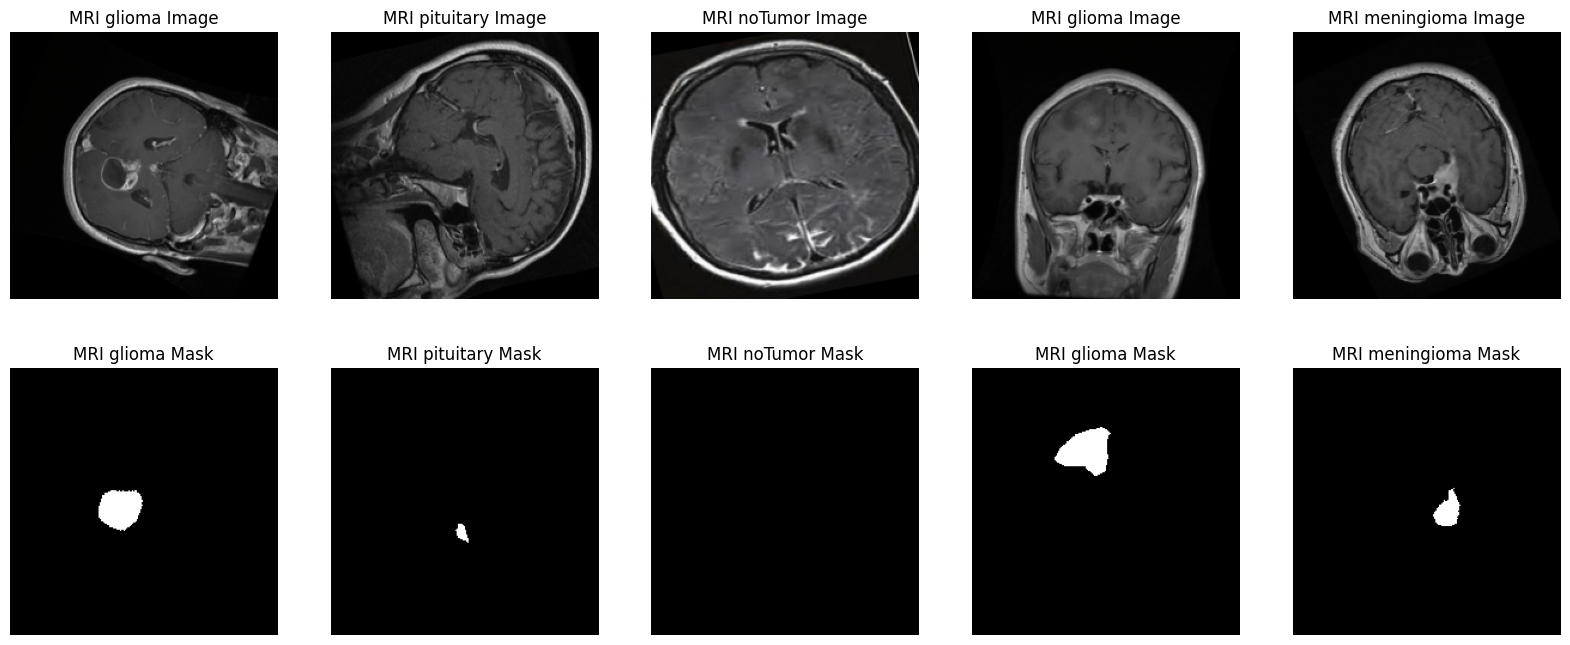

In [22]:
imagenet_mean_tensor  = torch.tensor([0.15717137, 0.15716884, 0.1571717]).view(3,1,1)
imagenet_std_tensor    = torch.tensor([0.17174117, 0.17173925, 0.17174085]).view(3,1,1)
#imagenet_mean_tensor  = torch.tensor([1, 1, 1]).view(3,1,1)
#imagenet_std_tensor    = torch.tensor([0, 0, 0]).view(3,1,1)
def denormalize(tensor):
    return (tensor * imagenet_std_tensor + imagenet_mean_tensor).clamp(0, 1)

images, masks, labels = next(iter(train_loader))
print(images.shape)  # (batch_size, 3, 224, 224)
print(images.shape)   # (batch_size, 1, 224, 224)

images_to_show = images[:20]
masks_to_show = masks[:20]
labels_to_show = labels[:20]
print("ready")


plt.figure(figsize=(20,8))

for i in range(5):
    # Image
    plt.subplot(2,5,i+1)
    plt.title(f"MRI {class_names[labels[i].item()]} Image")
    showImg = denormalize(images_to_show[i]).permute(1,2,0).numpy()
    plt.imshow(showImg)
    plt.axis('off')

    # Mask
    plt.subplot(2,5,i+6)
    plt.title(f"MRI {class_names[labels[i].item()]} Mask")
    showMask = masks_to_show[i].numpy()
    plt.imshow(showMask, cmap='gray')
    plt.axis('off')

plt.show()